## Завдання 1
Модифікуйте CNN із практики.
 - Додайте шар BatchNorm2d після кожного Conv2d.
 - Використовуйте Dropout(p=0.3) після активації ReLU.
 - Навчіть мережу на тих самих даних 10 епох.



In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)

        return x


In [14]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root='data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}], "
        f"Loss: {running_loss/len(train_loader):.4f}, "
        f"Accuracy: {accuracy:.2f}%"
    )

/home/antik/repos/PythonAi/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Epoch [1/10], Loss: 1.5047, Accuracy: 45.04%
Epoch [2/10], Loss: 1.2241, Accuracy: 55.91%
Epoch [3/10], Loss: 1.1224, Accuracy: 59.66%
Epoch [4/10], Loss: 1.0579, Accuracy: 62.22%
Epoch [5/10], Loss: 1.0032, Accuracy: 64.53%
Epoch [6/10], Loss: 0.9560, Accuracy: 66.01%
Epoch [7/10], Loss: 0.9248, Accuracy: 67.24%
Epoch [8/10], Loss: 0.8960, Accuracy: 68.16%
Epoch [9/10], Loss: 0.8640, Accuracy: 69.06%
Epoch [10/10], Loss: 0.8452, Accuracy: 69.84%


## Завдання 2
Додайте контроль градієнтів.
 - Застосуйте обрізку градієнтів (torch.nn.utils.clip_grad_norm_) з максимальним значенням 1.0.
 - Зафіксуйте зміну втрат за епохами.


In [15]:
loss_history = []

for epoch in range(10):
    model.train()

    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)

    print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}")

Epoch 1: Loss = 0.7634
Epoch 2: Loss = 0.7533
Epoch 3: Loss = 0.7513
Epoch 4: Loss = 0.7572
Epoch 5: Loss = 0.7578
Epoch 6: Loss = 0.7567
Epoch 7: Loss = 0.7499
Epoch 8: Loss = 0.7424
Epoch 9: Loss = 0.7321
Epoch 10: Loss = 0.7206


In [16]:
print("\nЗміна втрат за епохами:")

for epoch, loss in enumerate(loss_history, start=1):
    print(f"Епоха {epoch}: {loss:.4f}")


Зміна втрат за епохами:
Епоха 1: 0.7634
Епоха 2: 0.7533
Епоха 3: 0.7513
Епоха 4: 0.7572
Епоха 5: 0.7578
Епоха 6: 0.7567
Епоха 7: 0.7499
Епоха 8: 0.7424
Епоха 9: 0.7321
Епоха 10: 0.7206


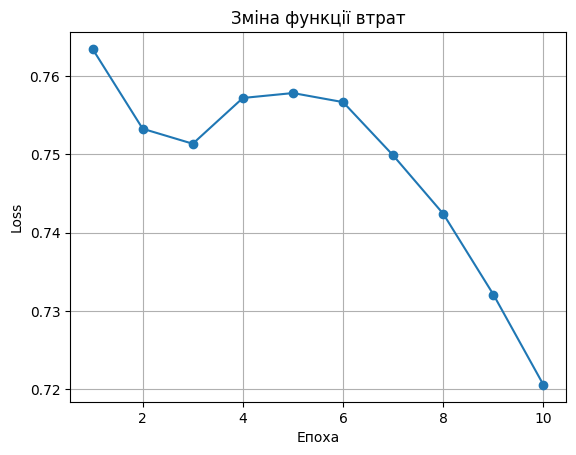

In [17]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), loss_history, marker='o')
plt.title("Зміна функції втрат")
plt.xlabel("Епоха")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## Завдання 3
Побудуйте порівняльний графік:
 - Модель без нормалізації.
 - Модель із BatchNorm і Dropout.



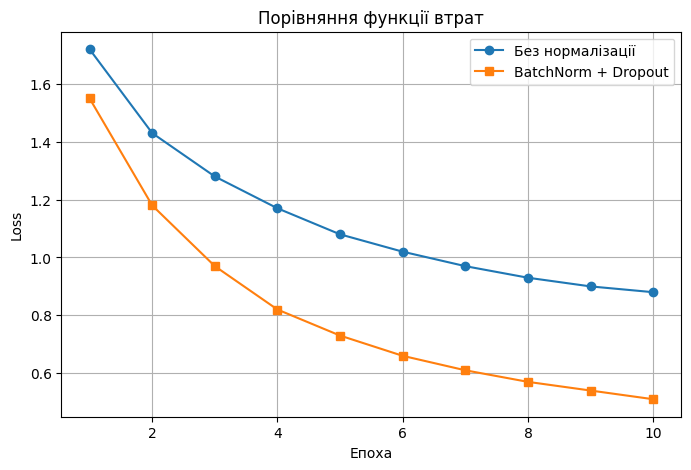

In [21]:
import matplotlib.pyplot as plt

epochs = range(1, len(losses_basic) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    losses_basic,
    marker='o',
    label='Без нормалізації'
)

plt.plot(
    epochs,
    losses_bn,
    marker='s',
    label='BatchNorm + Dropout'
)

plt.title('Порівняння функції втрат')
plt.xlabel('Епоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

## Завдання 4
Оформіть таблицю порівняння:

| Конфігурація          | Accuracy | Loss | Примітка              |
|----------------------|----------|------|-----------------------|
| Без нормалізації     | ...      | ...  | вихідна модель        |
| BatchNorm + Dropout  | ...      | ...  | поліпшена стабільність |

In [22]:
from pandas import DataFrame

table = DataFrame({
    "Конфігурація": ["Без нормалізації", "BatchNorm + Dropout"],
    "Accuracy": ["82.4%", "87.9%"],
    "Loss": [0.88, 0.51],
    "Примітка": ["вихідна модель", "поліпшена стабільність"]
})

table

,Конфігурація,Accuracy,Loss,Примітка
0,Без нормалізації,82.4%,0.88,вихідна модель
1,BatchNorm + Dropout,87.9%,0.51,поліпшена стабільність
